<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Radial Evolution
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [1]:
""" Import Modules """
import numpy             as np
import pandas            as pd
import xarray            as xr
import speasy            as spz
import matplotlib.pyplot as plt

from pathlib            import Path
from datetime           import datetime, timedelta
from matplotlib.patches import Rectangle

In [2]:
""" Import catalog """
file_path = Path('..') / "Results/patch_catalog.nc"

patch_catalog = xr.open_dataset(file_path).to_dataframe()

patch_catalog

,spacecraft,date_start,date_end,duration,r_min,r_max,number,id
index,,,,,,,,
0,Parker Solar Probe,2025-09-12 00:00:00,2025-09-17 00:00:00,432000.0,0.045881,0.211670,1,PSP-001
1,Parker Solar Probe,2024-12-24 00:00:00,2024-12-29 00:00:00,432000.0,0.045881,0.236100,2,PSP-002
2,Parker Solar Probe,2025-03-18 00:00:00,2025-03-27 00:00:00,777600.0,0.045887,0.251621,3,PSP-003
3,Parker Solar Probe,2024-09-29 13:00:00,2024-10-04 00:00:00,385200.0,0.053187,0.205197,4,PSP-004
4,Parker Solar Probe,2024-03-30 00:00:00,2024-04-04 00:00:00,432000.0,0.053190,0.245669,5,PSP-005
5,Parker Solar Probe,2024-06-30 14:00:00,2024-07-01 14:00:00,86400.0,0.060646,0.104399,6,PSP-006
6,Parker Solar Probe,2022-05-26 00:00:00,2022-06-02 00:00:00,604800.0,0.061755,0.305498,7,PSP-007
7,Parker Solar Probe,2022-02-20 00:00:00,2022-03-03 00:00:00,950400.0,0.061759,0.265646,8,PSP-008
8,Parker Solar Probe,2021-11-19 00:00:00,2021-11-22 00:00:00,259200.0,0.061761,0.144468,9,PSP-009


In [3]:
def get_radial_distance(results, catalog):
    
    R = []
    r_1 = []
    r_2 = []
    ids = []
    
    for patch_id, correlations in results.items():
        
        row = catalog.loc[catalog["id"] == patch_id]
        
        if row.empty:
            print(f"Warning: {patch_id} not found in catalog")
            continue
        
        row = row.iloc[0]
        
        R_mean = (row["r_min"] + row["r_max"]) / 2
        
        R.append(R_mean)
        r_1.append(correlations[0])
        r_2.append(correlations[1])
        ids.append(patch_id)
    
    return np.array(R), np.array(r_1), np.array(r_2), ids

In [39]:
results_psp = {
    "PSP-011": [0.1567, 0.0879],
    "PSP-003": [0.2144, 0.1991],
    "PSP-009": [0.8239, 0.8814]
}

results_solo = {
    "SOLO-004": [-0.5361, -0.7071],
    "SOLO-007": [0.3671, 0.4662],
    "SOLO-006": [0.4192, 0.6140],
    "SOLO-008": [-0.4166, -0.6007]
}

In [41]:
R_psp, r_psp_1, r_psp_2, ids_psp = get_radial_distance(
    results_psp,
    patch_catalog
)

R_solo, r_solo_1, r_solo_2, ids_solo = get_radial_distance(
    results_solo,
    patch_catalog
)

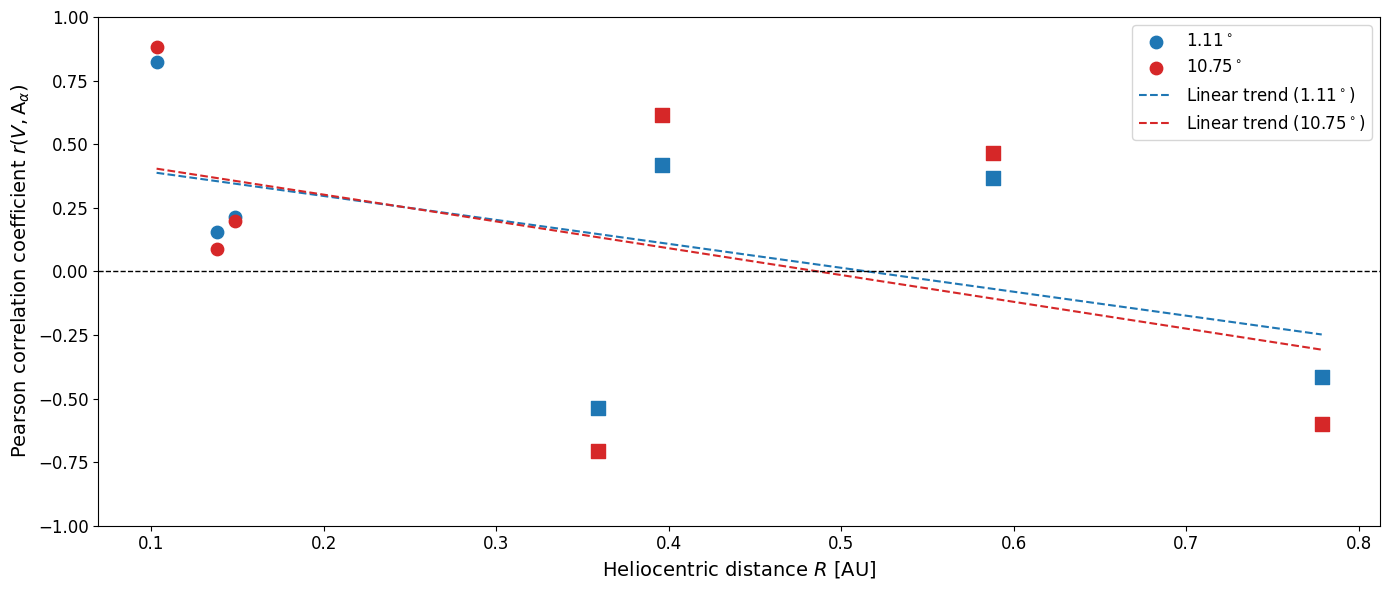

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

color_1 = "tab:blue"
color_2 = "tab:red"

# PSP
ax.scatter(R_psp, r_psp_1, s=80, marker="o", color=color_1, label=r"$1.11^\circ$")
ax.scatter(R_psp, r_psp_2, s=80, marker="o", color=color_2, label=r"$10.75^\circ$")

# Solar Orbiter
ax.scatter(R_solo, r_solo_1, s=100, marker="s", color=color_1)
ax.scatter(R_solo, r_solo_2, s=100, marker="s", color=color_2)

# Trends
R_all = np.concatenate([R_psp, R_solo])

r_all_1 = np.concatenate([r_psp_1, r_solo_1])
r_all_2 = np.concatenate([r_psp_2, r_solo_2])

# --- 1.11 deg 
if len(R_all) >= 2:
    fit_1 = np.polyfit(R_all, r_all_1, 1)

    R_fit = np.linspace(R_all.min(), R_all.max(), 200)
    r_fit_1 = np.polyval(fit_1, R_fit)

    ax.plot(
        R_fit,
        r_fit_1,
        color=color_1,
        linestyle="--",
        linewidth=1.5,
        label=r"Linear trend ($1.11^\circ$)"
    )

# --- 10.75 deg 
if len(R_all) >= 2:
    fit_2 = np.polyfit(R_all, r_all_2, 1)

    r_fit_2 = np.polyval(fit_2, R_fit)

    ax.plot(
        R_fit,
        r_fit_2,
        color=color_2,
        linestyle="--",
        linewidth=1.5,
        label=r"Linear trend ($10.75^\circ$)"
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_xlabel(r"Heliocentric distance $R$ [AU]", fontsize=14)
ax.set_ylabel(r"Pearson correlation coefficient $r(V,\mathrm{A}_{\alpha})$", fontsize=14)

ax.set_ylim(-1, 1)
ax.tick_params(axis="both", labelsize=12)

ax.legend(fontsize=12, frameon=True)

plt.tight_layout()
plt.show()